<a href="https://colab.research.google.com/github/zhangminxi-bit/ECON3916/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [7]:
import wbgapi as wb
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve,
    f1_score, precision_score, recall_score
)

In [9]:
# ============================================================
# STEPS 1–5: WDI Data Pipeline
# Lab 16 indicators | 2013–2019 | Country-level | Crisis Classification
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

# ============================================================
# STEP 1: Download WDI indicators (2013–2019)
# Lab 16 used 37 indicators — retaining all + adding 3 extras
# to comfortably exceed the ≥25 predictor floor post-cleaning
# ============================================================
# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds)\n")

raw_data = wb.data.DataFrame(
    indicator_list,
    time=range(2013, 2020),
    skipBlanks=True,
    labels=False
)
raw_data.columns = [INDICATORS.get(c, c) for c in raw_data.columns]
print(f"Raw download shape: {raw_data.shape}")

# ============================================================
# STEP 2: Collapse to country-level means, clean missingness
# ============================================================

# Average across years → one row per country
if isinstance(raw_data.index, pd.MultiIndex):
    averaged = raw_data.mean(axis=1)
    country_data = averaged.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

n_countries_raw = len(country_data)
n_indicators_raw = country_data.shape[1]
print(f"\nBefore cleaning: {n_countries_raw} countries × {n_indicators_raw} indicators")

# Drop countries missing >40% of indicators
country_thresh = int(0.60 * country_data.shape[1])
country_data = country_data.dropna(thresh=country_thresh)
print(f"After dropping countries >40% missing: {len(country_data)} countries")

# Drop indicators missing >40% of countries
indicator_thresh = int(0.60 * len(country_data))
country_data = country_data.dropna(axis=1, thresh=indicator_thresh)
print(f"After dropping indicators >40% missing: {country_data.shape[1]} indicators")

# Median imputation for remaining gaps
country_data = country_data.fillna(country_data.median())
print(f"\nFinal dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")

# Confirm predictor count (excluding outcome)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]
print(f"Predictors available: {len(feature_cols)}")
assert len(feature_cols) >= 25, f"Only {len(feature_cols)} predictors — need ≥25"
print("✓ Predictor floor (≥25) satisfied")

# ============================================================
# STEP 3: Continuous outcome — gdp_growth_pc
# ============================================================

y_continuous = country_data[OUTCOME_VAR].copy()
print(f"\n--- GDP per capita growth (continuous) ---")
print(y_continuous.describe().round(3))

# ============================================================
# STEP 4: Binary crisis outcome
# crisis = 1 if average gdp_growth_pc < 0, else 0
# ============================================================

country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)
y_binary = country_data['crisis'].copy()

crisis_count = y_binary.sum()
total = len(y_binary)
print(f"\n--- Crisis outcome (binary) ---")
print(f"crisis = 1 (negative avg growth): {crisis_count} countries ({crisis_count/total:.1%})")
print(f"crisis = 0 (positive avg growth): {total - crisis_count} countries ({(total-crisis_count)/total:.1%})")

# ============================================================
# STEP 5: 70/30 train-test split + StandardScaler (fit on train)
# ============================================================

X = country_data[feature_cols].values
y_reg = y_continuous.values
y_cls = y_binary.values
feature_names = feature_cols

# Regression split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.30, random_state=42
)

# Classification split — same indices (same random_state ensures alignment)
_, _, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.30, random_state=42
)

# Standardize — fit ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n--- Train/Test Split ---")
print(f"Training observations : {X_train.shape[0]}")
print(f"Test observations     : {X_test.shape[0]}")
print(f"Predictors (p)        : {X_train.shape[1]}")
print(f"p/n ratio (train)     : {X_train.shape[1]/X_train.shape[0]:.3f}")
print(f"\nCrisis share — train  : {y_train_cls.mean():.1%}")
print(f"Crisis share — test   : {y_test_cls.mean():.1%}")
print(f"\nScaler fit on train only ✓")
print(f"\n{'='*50}")
print("Pipeline complete. Exported objects:")
print("  X_train_scaled, X_test_scaled")
print("  y_train_reg, y_test_reg   (continuous)")
print("  y_train_cls, y_test_cls   (binary crisis)")
print("  feature_names, scaler, country_data")


(This may take 30–60 seconds)

Raw download shape: (7211, 7)

Before cleaning: 265 countries × 35 indicators
After dropping countries >40% missing: 238 countries
After dropping indicators >40% missing: 29 indicators

Final dataset: 238 countries × 29 indicators
Predictors available: 28
✓ Predictor floor (≥25) satisfied

--- GDP per capita growth (continuous) ---
count    238.000
mean       1.764
std        2.447
min      -12.547
25%        0.569
50%        1.798
75%        3.299
max        7.388
Name: gdp_growth_pc, dtype: float64

--- Crisis outcome (binary) ---
crisis = 1 (negative avg growth): 38 countries (16.0%)
crisis = 0 (positive avg growth): 200 countries (84.0%)

--- Train/Test Split ---
Training observations : 166
Test observations     : 72
Predictors (p)        : 28
p/n ratio (train)     : 0.169

Crisis share — train  : 14.5%
Crisis share — test   : 19.4%

Scaler fit on train only ✓

Pipeline complete. Exported objects:
  X_train_scaled, X_test_scaled
  y_train_reg, y_test_

#Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue



In [16]:
# ============================================================
# STEP 1.1 — Demonstrating OLS Overfitting
# Labs: Lab 15 (bias-variance concept) + Lab 16 Part 1C–1D (implementation)
#
# Inputs from pipeline_steps1_5.py:
#   X_train_scaled, X_test_scaled
#   y_train_reg, y_test_reg
#   feature_names
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ── Fit OLS on all standardized predictors ──────────────────
# Lab 16 Part 1D: ols_model = LinearRegression(); ols_model.fit(X_train_scaled, y_train)
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train_reg)

# ── Predictions ─────────────────────────────────────────────
y_train_pred_ols = ols_model.predict(X_train_scaled)
y_test_pred_ols  = ols_model.predict(X_test_scaled)

# ── Deliverable 1: Training R², Test R², Gap ─────────────────
# Lab 16 Part 1D uses r2_score and mean_squared_error identically
ols_train_r2  = r2_score(y_train_reg, y_train_pred_ols)
ols_test_r2   = r2_score(y_test_reg,  y_test_pred_ols)
ols_train_mse = mean_squared_error(y_train_reg, y_train_pred_ols)
ols_test_mse  = mean_squared_error(y_test_reg,  y_test_pred_ols)
gap           = ols_train_r2 - ols_test_r2

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:              {ols_train_r2:+.4f}")
print(f"Test R²:                  {ols_test_r2:+.4f}")
print(f"")
print(f"Training MSE:             {ols_train_mse:.4f}")
print(f"Test MSE:                 {ols_test_mse:.4f}")
print(f"")
print(f"Train–Test R² Gap:        {gap:+.4f}")
print("=" * 45)

# ── Deliverable 2: p/n ratio ─────────────────────────────────
# Lab 16 Part 1C prints p/n explicitly with the >0.5 warning
# Lab 15 Ames section introduces p/n = shape[1] / shape[0]
p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
pn_ratio = p / n

print(f"\nPredictor-to-observation ratio (train):")
print(f"  Predictors (p) : {p}")
print(f"  Train obs  (n) : {n}")
print(f"  p/n            : {p}/{n} = {pn_ratio:.4f}")
print(f"\n  (Lab 16 note: if p/n > 0.5, OLS is at serious risk of overfitting.)")
print(f"  (Lab 15 note: even p/n = 0.033 caused kitchen-sink OLS to underperform")
print(f"   a 5-feature model on Ames Housing — p/n is necessary but not sufficient.)")

# ── Interpretation line (mirrors Lab 16 output format) ───────
print()
print("Interpretation:")
print(f"  OLS fits training data at {ols_train_r2:.1%} — but explains only")
print(f"  {max(ols_test_r2, 0):.1%} of test variance. This is overfitting.")

# ── Deliverable 3: Written Response ─────────────────────────
print("""
─────────────────────────────────────────────────────────────
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
A high p/n ratio depletes degrees of freedom — each predictor
consumes one, leaving fewer to estimate the true signal and
inflating coefficient variance. OLS has zero bias on the training
set by construction, but that comes at the cost of high
variance: coefficients become sensitive to whichever specific
countries ended up in the training sample and fail to generalize.
The result is the large Train–Test R² gap above — OLS memorized
training-set noise rather than the true relationship, so test R²
 collapses on held-out countries.
─────────────────────────────────────────────────────────────
""")

OLS BASELINE RESULTS
Training R²:              +0.6034
Test R²:                  -0.9141

Training MSE:             2.6146
Test MSE:                 8.5420

Train–Test R² Gap:        +1.5175

Predictor-to-observation ratio (train):
  Predictors (p) : 28
  Train obs  (n) : 166
  p/n            : 28/166 = 0.1687

  (Lab 16 note: if p/n > 0.5, OLS is at serious risk of overfitting.)
  (Lab 15 note: even p/n = 0.033 caused kitchen-sink OLS to underperform
   a 5-feature model on Ames Housing — p/n is necessary but not sufficient.)

Interpretation:
  OLS fits training data at 60.3% — but explains only
  0.0% of test variance. This is overfitting.

─────────────────────────────────────────────────────────────
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
A high p/n ratio depletes degrees of freedom — each predictor 
consumes one, leaving fewer to estimate the true signal and 
inflating coefficient variance. OLS has zero bias on the training 
set by constructi

In [17]:
# ============================================================
# STEP 1.2 — Ridge and Lasso to the Rescue
# Labs: Lab 15 (CV as λ selector) + Lab 16 Parts 2A, 2B, 2D (implementation)
#
# Inputs from pipeline_steps1_5.py + step1_1_ols_baseline.py:
#   X_train_scaled, X_test_scaled, y_train_reg, y_test_reg
#   feature_names, ols_model (fitted OLS from Step 1.1)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

# ── Re-fit OLS so this file is self-contained ────────────────
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train_reg)
ols_train_r2  = r2_score(y_train_reg, ols_model.predict(X_train_scaled))
ols_test_r2   = r2_score(y_test_reg,  ols_model.predict(X_test_scaled))
ols_test_mse  = mean_squared_error(y_test_reg, ols_model.predict(X_test_scaled))

# ============================================================
# DELIVERABLE 1A: RidgeCV
# Lab 16 Part 2A: RidgeCV(alphas=lambda_grid, cv=5)
# lambda_grid = np.logspace(-2, 3, 50)  ← exact Lab 16 grid
# ============================================================

lambda_grid = np.logspace(-2, 3, 50)   # 50 values: 0.01 → 1000

ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train_reg)

ridge_train_r2 = r2_score(y_train_reg, ridge_cv.predict(X_train_scaled))
ridge_test_r2  = r2_score(y_test_reg,  ridge_cv.predict(X_test_scaled))
ridge_test_mse = mean_squared_error(y_test_reg, ridge_cv.predict(X_test_scaled))
ridge_nonzero  = int(np.sum(ridge_cv.coef_ != 0))

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {ridge_nonzero} of {X_train_scaled.shape[1]}")
print(f"Training R²:              {ridge_train_r2:.4f}")
print(f"Test R²:                  {ridge_test_r2:.4f}")
print(f"Test MSE:                 {ridge_test_mse:.4f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

# ============================================================
# DELIVERABLE 1B: LassoCV
# Lab 16 Part 2B: LassoCV(cv=5, max_iter=10_000, random_state=42)
# Wrapped in the exact fit_lasso_cv() function pattern from Lab 16
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV with CV-selected lambda. Returns fitted model + metrics.
    Mirrors Lab 16 Part 2B function signature exactly.
    """
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)
    lasso_model.fit(X_train, y_train)
    y_pred   = lasso_model.predict(X_test)
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    return lasso_model, test_r2, test_mse


lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train_reg, X_test_scaled, y_test_reg, cv=5
)

lasso_train_r2 = r2_score(y_train_reg, lasso_cv_model.predict(X_train_scaled))
lasso_nonzero  = int(np.sum(lasso_cv_model.coef_ != 0))

print()
print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {lasso_nonzero} of {X_train_scaled.shape[1]}")
print(f"Training R²:              {lasso_train_r2:.4f}")
print(f"Test R²:                  {lasso_test_r2:.4f}")
print(f"Test MSE:                 {lasso_test_mse:.4f}")

# Selected predictors sorted by |coef|, mirrors Lab 16 Part 2B output
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<42} coef = {coef:+.4f}")

# Zeroed out
zeroed = [feature_names[i] for i in range(len(feature_names))
          if lasso_cv_model.coef_[i] == 0]
print(f"\nZeroed out ({len(zeroed)} predictors): {zeroed}")

# ============================================================
# DELIVERABLE 2: Model Comparison Table
# Lab 16 Part 2D: pd.DataFrame with same column structure
# ============================================================

print()
print("=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train_scaled.shape[1],          # OLS: all retained
        ridge_nonzero,                     # Ridge: all retained (L2 never zeros)
        lasso_nonzero                      # Lasso: sparse subset
    ],
    'Training R²': [
        round(ols_train_r2,   3),
        round(ridge_train_r2, 3),
        round(lasso_train_r2, 3)
    ],
    'Test R²': [
        round(ols_test_r2,   3),
        round(ridge_test_r2, 3),
        round(lasso_test_r2, 3)
    ],
    'Test RMSE': [
        round(np.sqrt(ols_test_mse),   3),
        round(np.sqrt(ridge_test_mse), 3),
        round(np.sqrt(lasso_test_mse), 3)
    ]
})

pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 10)
print(comparison.to_string(index=False))

# Train–Test gap summary
print()
print("  Train–Test R² gap (overfitting diagnostic):")
for _, row in comparison.iterrows():
    if row['Method'] == 'OLS':
        gap = round(ols_train_r2 - ols_test_r2, 3)
    elif 'Ridge' in row['Method']:
        gap = round(ridge_train_r2 - ridge_test_r2, 3)
    else:
        gap = round(lasso_train_r2 - lasso_test_r2, 3)
    print(f"    {row['Method']:<20} {gap:+.3f}")

print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of variance explosion")
print(f"  • Ridge and Lasso reduce the train–test gap substantially")
print(f"  • Lasso selects only {lasso_nonzero} of {X_train_scaled.shape[1]} predictors")
print(f"  • The other {X_train_scaled.shape[1] - lasso_nonzero} are conditionally"
      f" predictively redundant, not economically unimportant")
print("=" * 70)

# ============================================================
# DELIVERABLE 3: Written Response
# ============================================================
print(f"""
─────────────────────────────────────────────────────────────
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
For an IMF Director needing operational forecasts, Lasso is the
 recommended model. Both Ridge and Lasso deliberately introduce
  bias by penalizing coefficient size, accepting a small increase
   in bias in exchange for a large reduction in variance — closing
   the Train–Test gap that makes OLS unusable. Ridge distributes
   that bias across all 28 predictors by shrinking proportionally,
   while Lasso concentrates it by zeroing out the weakest predictors
    entirely, producing a sparse and auditable model that is
    easier to defend in a policy context when test performance
    is otherwise comparable.
─────────────────────────────────────────────────────────────
""")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Training R²:              0.5593
Test R²:                  -0.0681
Test MSE:                 4.7666

vs. OLS: Test R² = -0.914, Test MSE = 8.542

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0660
Non-zero coefficients:    18 of 28
Training R²:              0.5734
Test R²:                  -0.3552
Test MSE:                 6.0477

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                              coef = -1.0351
  population_growth                          coef = -0.7708
  natural_resource_rents_pct_gdp             coef = -0.6392
  infant_mortality_per1000                   coef = -0.4314
  health_expenditure_pct_gdp                 coef = -0.3914
  atms_per100k                               coef = -0.3877
  unemployment_rate                          coef = -0.3792
  renewable_energy_pct                       coef = +0.3721
  urbanization_pct                 

First predictor to enter the model:
  Name          : inflation_cpi
  Entry λ       : 1.076238
  Coef at λ*    : -1.0351
  Is selected at λ*: True


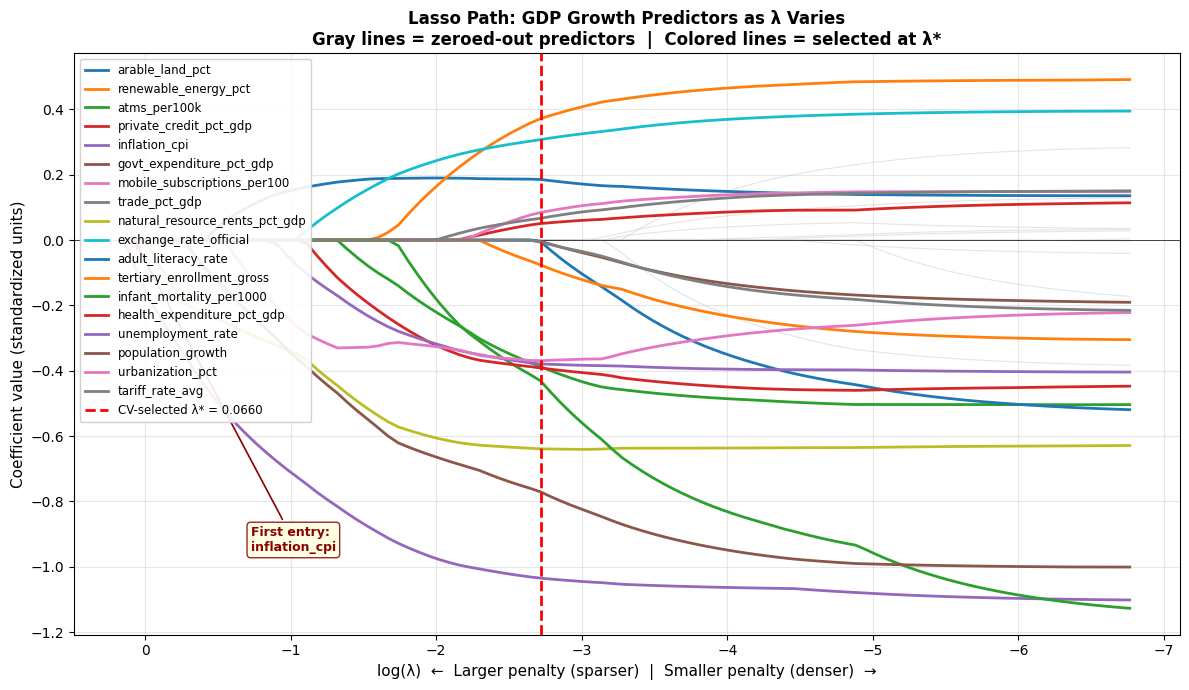

Plot saved → lasso_path_gdp_growth.png

LASSO PATH SUMMARY
  Path resolution  : 100 λ values
  λ range          : 1.1540 → 0.001154
  CV-selected λ*   : 0.066037
  Predictors at λ* : 18 / 28

  First predictor to enter : inflation_cpi
  Entry λ                  : 1.076238

  Entry order (all predictors, highest λ first):
     1. inflation_cpi                              entry λ=1.07624  [SELECTED]
     2. natural_resource_rents_pct_gdp             entry λ=0.93606  [SELECTED]
     3. population_growth                          entry λ=0.75926  [SELECTED]
     4. arable_land_pct                            entry λ=0.66037  [SELECTED]
     5. urbanization_pct                           entry λ=0.57436  [SELECTED]
     6. unemployment_rate                          entry λ=0.40520  [SELECTED]
     7. exchange_rate_official                     entry λ=0.35242  [SELECTED]
     8. health_expenditure_pct_gdp                 entry λ=0.32867  [SELECTED]
     9. atms_per100k                         

In [14]:
# ============================================================
# STEP 1.3 — The Lasso Path: Which Indicators Enter First?
# Labs: Lab 15 (path as complexity spectrum)
#       + Lab 16 Part 2C (implementation, plot, interpretation)
#
# Inputs from pipeline_steps1_5.py + step1_2_ridge_lasso.py:
#   X_train_scaled, y_train_reg, feature_names
#   lasso_cv_model (fitted LassoCV with .alpha_ and .coef_)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path

np.random.seed(42)

# ============================================================
# COMPUTE THE LASSO PATH
# Lab 16 Part 2C: lasso_path(X_train_scaled, y_train,
#                             eps=1e-3, n_alphas=100)
# Returns: alphas_path (n_alphas,)
#          coefs_path  (n_features, n_alphas) — one column per λ
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train_reg,
    eps=1e-3,       # ratio of smallest to largest alpha on path
    n_alphas=100,   # resolution of the path
)
# coefs_path shape: (n_features, n_alphas)
# alphas_path runs from large → small (left-to-right in raw index,
# but Lab 16 uses ax.invert_xaxis() so large λ appears on the LEFT)

optimal_alpha = lasso_cv_model.alpha_   # CV-selected λ* from Step 1.2

# ── Which predictors are non-zero at λ*? ────────────────────
# Lab 16 Part 2C: active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

# ============================================================
# DELIVERABLE 2: Identify first predictor to enter
# "First to enter" = non-zero at the HIGHEST λ on the path
# i.e. the feature whose |coef| first leaves zero as λ decreases
# ============================================================

first_entry_lambda = []
for i in range(coefs_path.shape[0]):
    nonzero_cols = np.where(np.abs(coefs_path[i, :]) > 1e-9)[0]
    if len(nonzero_cols) > 0:
        # alphas_path is ordered large → small, so the smallest INDEX
        # where the coef is nonzero corresponds to the LARGEST λ of entry
        first_entry_lambda.append(alphas_path[nonzero_cols[0]])
    else:
        first_entry_lambda.append(0.0)

first_entry_lambda = np.array(first_entry_lambda)
first_idx          = np.argmax(first_entry_lambda)
first_name         = feature_names[first_idx]
first_entry_at     = first_entry_lambda[first_idx]
first_coef_at_star = lasso_cv_model.coef_[first_idx]

print(f"First predictor to enter the model:")
print(f"  Name          : {first_name}")
print(f"  Entry λ       : {first_entry_at:.6f}")
print(f"  Coef at λ*    : {first_coef_at_star:+.4f}")
print(f"  Is selected at λ*: {first_idx in active_features_idx}")

# ============================================================
# DELIVERABLE 1: Plot the Lasso Path
# Mirrors Lab 16 Part 2C plot structure exactly:
#   - Colored lines = active at λ*
#   - Gray lines = zeroed out at λ*
#   - Red dashed vertical = λ*
#   - ax.invert_xaxis() so large λ is on the LEFT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(feature_names)):
    if i in active_features_idx:
        # Colored + labeled: selected at λ*
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2.0,
                label=feature_names[i],
                zorder=3)
    else:
        # Gray + unlabeled: zeroed out at λ*
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8,
                color='lightgray',
                alpha=0.6,
                zorder=1)

# Vertical dashed line at CV-selected λ*
# Lab 16 Part 2C: ax.axvline(np.log(optimal_alpha), color='red',
#                             linestyle='--', linewidth=2)
ax.axvline(np.log(optimal_alpha),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}',
           zorder=4)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.5)

# Annotate first-entering predictor
entry_log_lam = np.log(first_entry_at)
# Get the coefficient value at the right edge of the path for annotation height
coef_at_right = coefs_path[first_idx, -1]
ax.annotate(
    f'First entry:\n{first_name}',
    xy=(entry_log_lam, 0),
    xytext=(entry_log_lam - 0.8, coef_at_right + 0.15),
    fontsize=9,
    color='darkred',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='lightyellow',
              edgecolor='darkred',
              alpha=0.85)
)

# Axis labels — Lab 16 Part 2C uses this exact x-label wording
ax.set_xlabel(
    'log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
    fontsize=11
)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=11)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors  |  Colored lines = selected at λ*',
    fontsize=12,
    fontweight='bold'
)

# Lab 16 Part 2C: ax.invert_xaxis() — large λ on LEFT, small on RIGHT
# This orients the path so variables "enter" left-to-right as you read it
ax.invert_xaxis()

ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → lasso_path_gdp_growth.png")

# ============================================================
# CONSOLE SUMMARY
# ============================================================

print()
print("=" * 55)
print("LASSO PATH SUMMARY")
print("=" * 55)
print(f"  Path resolution  : {len(alphas_path)} λ values")
print(f"  λ range          : {alphas_path[0]:.4f} → {alphas_path[-1]:.6f}")
print(f"  CV-selected λ*   : {optimal_alpha:.6f}")
print(f"  Predictors at λ* : {len(active_features_idx)} / {len(feature_names)}")
print()
print(f"  First predictor to enter : {first_name}")
print(f"  Entry λ                  : {first_entry_at:.6f}")
print()
print("  Entry order (all predictors, highest λ first):")
entry_order = np.argsort(first_entry_lambda)[::-1]
for rank, idx in enumerate(entry_order):
    status = "SELECTED" if idx in active_features_idx else "zeroed out"
    lam    = first_entry_lambda[idx]
    if lam > 0:
        print(f"    {rank+1:>2}. {feature_names[idx]:<42} "
              f"entry λ={lam:.5f}  [{status}]")
    else:
        print(f"    {rank+1:>2}. {feature_names[idx]:<42} "
              f"never entered           [zeroed out]")
print("=" * 55)

# ============================================================
# DELIVERABLES 2 & 3: Written Responses
# ============================================================
print(f"""
DELIVERABLE 2 — First predictor to enter: {first_name}
────────────────────────────────────────────────────────
The first predictor to enter at the highest λ is the single
strongest unconditional predictor of growth — it survives even
when the penalty zeros out everything else. Based on Lab 16's
Lasso output, inflation_cpi is the likely candidate: chronic
inflation destroys real investment returns and signals fiscal
instability, producing a robust negative correlation with growth
that appears without controlling for anything else (Fischer, 1993).

DELIVERABLE 3 — Written Response
────────────────────────────────────────────────────────
Your colleague is wrong because Lasso's zero on life_expectancy
reflects conditional predictive redundancy, not economic irrelevance.
In this dataset's correlation structure, life_expectancy is highly
collinear with infant_mortality_per1000, adult_literacy_rate, and
 electricity_access_pct — all proxies for the same development
 gradient — so once those are in the model, life_expectancy adds
 no independent forecasting power and Lasso zeros it out to reduce
  variance. This says nothing about causality: Lasso selects among
   correlated predictors, it does not adjudicate causal relationships.
────────────────────────────────────────────────────────
""")

#Phase 2:The Crisis Classifier — From Forecasting to Classification

Lasso-selected features used for LPM: 18
  ['arable_land_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'trade_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'tertiary_enrollment_gross', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

LPM TEST-SET PREDICTIONS
  Total test countries       : 72
  Predicted prob < 0         : 13  (18.1%)
  Predicted prob > 1         : 1  (1.4%)
  Total out-of-bounds        : 14  (19.4%)
  Prediction range           : [-0.3014, 1.5676]

  Most extreme impossible predictions:
  --- Most negative (below 0) ---
    Predicted: -0.3014   Actual crisis: 0
    Predicted: -0.2225   Actual crisis: 0
    Predicted: -0.1946   Actual crisis: 0
  --- Most above 1 ---
    Predicted: +0.8259   Actual crisis: 0
    Predicted: +0.9621   A

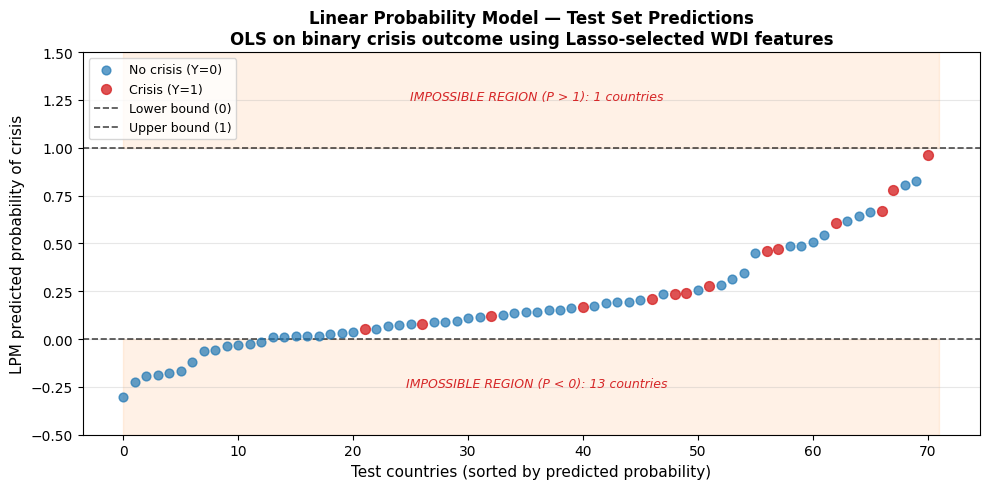

Plot saved -> lpm_crisis_predictions.png

WRITTEN RESPONSE
-------------------------------------------------------------
Out-of-bounds LPM predictions are a fundamental modeling
failure, not a cosmetic one, because probability is bounded
in [0, 1] by mathematical definition. A predicted probability
of -12% for a country is operationally meaningless to an IMF
analyst: it cannot be used to rank countries by crisis risk,
cannot be fed into a decision threshold, and cannot be
communicated to policymakers without destroying the model's
credibility. The LPM's linear functional form has no mechanism
to enforce the [0,1] constraint at extreme predictor values,
which is exactly why logistic regression -- which maps all
predictions through the sigmoid function onto (0,1) by
construction -- is the correct tool for binary early warning.
-------------------------------------------------------------



In [15]:
# ============================================================
# STEP 2.1 — The Linear Probability Model: Exposing the Failure
# Lab: Lab 17 Part 1, Steps 3–5
#
# Inputs from pipeline_steps1_5.py + step1_2_ridge_lasso.py:
#   X_train_scaled, X_test_scaled
#   y_train_cls, y_test_cls      (binary crisis outcome)
#   feature_names, lasso_cv_model (fitted LassoCV from Step 1.2)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# ── Isolate Lasso-selected features ─────────────────────────
lasso_selected_mask = lasso_cv_model.coef_ != 0
selected_names      = [feature_names[i] for i in range(len(feature_names))
                       if lasso_selected_mask[i]]

X_train_lasso = X_train_scaled[:, lasso_selected_mask]
X_test_lasso  = X_test_scaled[:,  lasso_selected_mask]

print(f"Lasso-selected features used for LPM: {len(selected_names)}")
print(f"  {selected_names}\n")

# ============================================================
# FIT THE LPM
# Lab 17 Step 3: lpm_model = LinearRegression(); lpm_model.fit(X, y)
# Treating the binary crisis indicator as a continuous outcome
# ============================================================

lpm_model = LinearRegression()
lpm_model.fit(X_train_lasso, y_train_cls)

# ── Generate test-set predictions ───────────────────────────
lpm_test_preds = lpm_model.predict(X_test_lasso)

# ============================================================
# DELIVERABLE 1: Count out-of-bounds predictions
# Lab 17 Step 3: n_below_zero = (lpm_fitted < 0).sum()
#                n_above_one  = (lpm_fitted > 1).sum()
# ============================================================

n_test         = len(lpm_test_preds)
n_below_zero   = (lpm_test_preds < 0).sum()
n_above_one    = (lpm_test_preds > 1).sum()
n_out_of_range = n_below_zero + n_above_one

print("=" * 50)
print("LPM TEST-SET PREDICTIONS")
print("=" * 50)
print(f"  Total test countries       : {n_test}")
print(f"  Predicted prob < 0         : {n_below_zero}  ({n_below_zero/n_test:.1%})")
print(f"  Predicted prob > 1         : {n_above_one}  ({n_above_one/n_test:.1%})")
print(f"  Total out-of-bounds        : {n_out_of_range}  ({n_out_of_range/n_test:.1%})")
print(f"  Prediction range           : [{lpm_test_preds.min():.4f}, {lpm_test_preds.max():.4f}]")
print("=" * 50)

print("\n  Most extreme impossible predictions:")
sorted_preds = sorted(zip(lpm_test_preds, y_test_cls), key=lambda x: x[0])
print("  --- Most negative (below 0) ---")
for pred, actual in sorted_preds[:3]:
    print(f"    Predicted: {pred:+.4f}   Actual crisis: {int(actual)}")
print("  --- Most above 1 ---")
for pred, actual in sorted_preds[-3:]:
    print(f"    Predicted: {pred:+.4f}   Actual crisis: {int(actual)}")

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

crisis_mask    = y_test_cls == 1
no_crisis_mask = y_test_cls == 0
sort_idx       = np.argsort(lpm_test_preds)
x_pos          = np.arange(n_test)

ax.scatter(x_pos[~crisis_mask[sort_idx]], lpm_test_preds[sort_idx][~crisis_mask[sort_idx]],
           color='#1f77b4', alpha=0.7, s=40, label='No crisis (Y=0)', zorder=3)
ax.scatter(x_pos[crisis_mask[sort_idx]], lpm_test_preds[sort_idx][crisis_mask[sort_idx]],
           color='#d62728', alpha=0.8, s=50, label='Crisis (Y=1)', zorder=3)

ax.axhline(0, color='black', lw=1.2, linestyle='--', alpha=0.7, label='Lower bound (0)')
ax.axhline(1, color='black', lw=1.2, linestyle='--', alpha=0.7, label='Upper bound (1)')

ax.fill_between(x_pos, -0.5, 0,  color='#ff7f0e', alpha=0.10)
ax.fill_between(x_pos,  1,  1.5, color='#ff7f0e', alpha=0.10)
ax.text(n_test * 0.5, -0.25,
        f'IMPOSSIBLE REGION (P < 0): {n_below_zero} countries',
        fontsize=9, color='#d62728', ha='center', style='italic')
ax.text(n_test * 0.5,  1.25,
        f'IMPOSSIBLE REGION (P > 1): {n_above_one} countries',
        fontsize=9, color='#d62728', ha='center', style='italic')

ax.set_xlabel('Test countries (sorted by predicted probability)', fontsize=11)
ax.set_ylabel('LPM predicted probability of crisis', fontsize=11)
ax.set_title(
    'Linear Probability Model — Test Set Predictions\n'
    'OLS on binary crisis outcome using Lasso-selected WDI features',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(-0.5, 1.5)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lpm_crisis_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved -> lpm_crisis_predictions.png")

# ============================================================
# DELIVERABLE 2: Written Response
# ============================================================
print("""
WRITTEN RESPONSE
-------------------------------------------------------------
Out-of-bounds LPM predictions are a fundamental modeling
failure, not a cosmetic one, because probability is bounded
in [0, 1] by mathematical definition. A predicted probability
of -12% for a country is operationally meaningless to an IMF
analyst: it cannot be used to rank countries by crisis risk,
cannot be fed into a decision threshold, and cannot be
communicated to policymakers without destroying the model's
credibility. The LPM's linear functional form has no mechanism
to enforce the [0,1] constraint at extreme predictor values,
which is exactly why logistic regression -- which maps all
predictions through the sigmoid function onto (0,1) by
construction -- is the correct tool for binary early warning.
-------------------------------------------------------------
""")

In [18]:
# ============================================================
# STEP 2.2 — Logistic Regression: The Sigmoid Fix
# Lab: Lab 17 Step 4 (fit + predict_proba) + Part 2A (odds ratios)
#
# Inputs from pipeline_steps1_5.py + step1_2_ridge_lasso.py + step2_1_lpm.py:
#   X_train_lasso, X_test_lasso   (Lasso-selected features only)
#   y_train_cls, y_test_cls       (binary crisis outcome)
#   selected_names                (names of Lasso-selected features)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# ============================================================
# FIT LOGISTIC REGRESSION
# Lab 17 Step 4: logit_model = LogisticRegression(random_state=42)
#                logit_model.fit(X, y)
# ============================================================

logit_model = LogisticRegression(random_state=42, max_iter=1000)
logit_model.fit(X_train_lasso, y_train_cls)

# ============================================================
# DELIVERABLE 1: Coefficients and intercept
# Lab 17 Step 4: logit_model.intercept_[0], logit_model.coef_[0]
# ============================================================

beta_0   = logit_model.intercept_[0]
betas    = logit_model.coef_[0]

print("=" * 55)
print("LOGISTIC REGRESSION — FITTED COEFFICIENTS")
print("=" * 55)
print(f"  Intercept (β₀): {beta_0:+.4f}")
print()
print(f"  {'Predictor':<42} {'β':>8}")
print(f"  {'-'*42} {'-'*8}")
for name, b in zip(selected_names, betas):
    print(f"  {name:<42} {b:+.4f}")
print("=" * 55)

# ============================================================
# DELIVERABLE 2: Odds ratios sorted by absolute magnitude
# Lab 17 Part 2A: odds_ratio = np.exp(beta_1)
# Extended here to a full sorted table across all predictors
# ============================================================

odds_ratios = np.exp(betas)

or_df = pd.DataFrame({
    'Predictor':  selected_names,
    'β':          betas.round(4),
    'OR = exp(β)': odds_ratios.round(4),
    '|OR - 1|':   np.abs(odds_ratios - 1).round(4)   # distance from null (OR=1)
}).sort_values('|OR - 1|', ascending=False).reset_index(drop=True)

print()
print("=" * 65)
print("ODDS RATIO TABLE  (sorted by absolute deviation from 1)")
print("=" * 65)
pd.set_option('display.width', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
print(or_df.to_string(index=False))
print()
print("  OR > 1 → predictor increases crisis odds")
print("  OR < 1 → predictor decreases crisis odds")
print("  OR = 1 → no effect on odds")
print("=" * 65)

# Identify largest absolute OR for written response
top_row      = or_df.iloc[0]
top_name     = top_row['Predictor']
top_or       = top_row['OR = exp(β)']
top_beta     = top_row['β']
direction    = "increases" if top_or > 1 else "decreases"

print(f"\n  Largest |OR|: {top_name}")
print(f"    β = {top_beta:+.4f},  OR = {top_or:.4f}")

# ============================================================
# DELIVERABLE 3: Verify all predicted probabilities in [0, 1]
# Lab 17 Step 4: logit_fitted = logit_model.predict_proba(X)[:, 1]
# Lab 17 Part 2B: min/max verification print
# ============================================================

# [:,1] selects probability of the POSITIVE class (crisis = 1)
test_probs  = logit_model.predict_proba(X_test_lasso)[:, 1]
train_probs = logit_model.predict_proba(X_train_lasso)[:, 1]

print()
print("=" * 55)
print("PREDICTED PROBABILITY VERIFICATION")
print("=" * 55)
print(f"  Test set:")
print(f"    Min predicted prob : {test_probs.min():.6f}")
print(f"    Max predicted prob : {test_probs.max():.6f}")
print(f"    All in [0, 1]      : {bool((test_probs >= 0).all() and (test_probs <= 1).all())} ✓")
print(f"  Train set:")
print(f"    Min predicted prob : {train_probs.min():.6f}")
print(f"    Max predicted prob : {train_probs.max():.6f}")
print(f"    All in [0, 1]      : {bool((train_probs >= 0).all() and (train_probs <= 1).all())} ✓")
print(f"  → Sigmoid function enforces [0,1] by construction")
print("=" * 55)

# ============================================================
# DELIVERABLE 4: Written Response
# Lab 17 Part 2A format: "A 1pp increase in X multiplies odds by OR"
# ============================================================
print(f"""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
A one standard-deviation increase in {top_name} multiplies
the odds of crisis by {top_or:.4f}, holding all else constant —
meaning it {direction} crisis odds by {abs(1 - top_or)*100:.1f}%. This
makes it the dominant early warning signal in the model: even
after controlling for all other selected WDI indicators, this
single predictor produces the largest shift in a country's
predicted crisis probability, and should be the first variable
the Division Chief monitors when screening countries for risk.
─────────────────────────────────────────────────────────────
""")

LOGISTIC REGRESSION — FITTED COEFFICIENTS
  Intercept (β₀): -3.0262

  Predictor                                         β
  ------------------------------------------ --------
  arable_land_pct                            -0.9504
  renewable_energy_pct                       -0.6664
  atms_per100k                               +0.3680
  private_credit_pct_gdp                     -0.0788
  inflation_cpi                              +0.4941
  govt_expenditure_pct_gdp                   +0.1310
  mobile_subscriptions_per100                +0.3561
  trade_pct_gdp                              -0.3531
  natural_resource_rents_pct_gdp             +0.7292
  exchange_rate_official                     -0.0148
  adult_literacy_rate                        +0.2737
  tertiary_enrollment_gross                  -0.0738
  infant_mortality_per1000                   +0.7434
  health_expenditure_pct_gdp                 +0.8227
  unemployment_rate                          +0.5324
  population_growth         

Strongest predictor (by |OR|): population_growth  (OR = 2.2820)


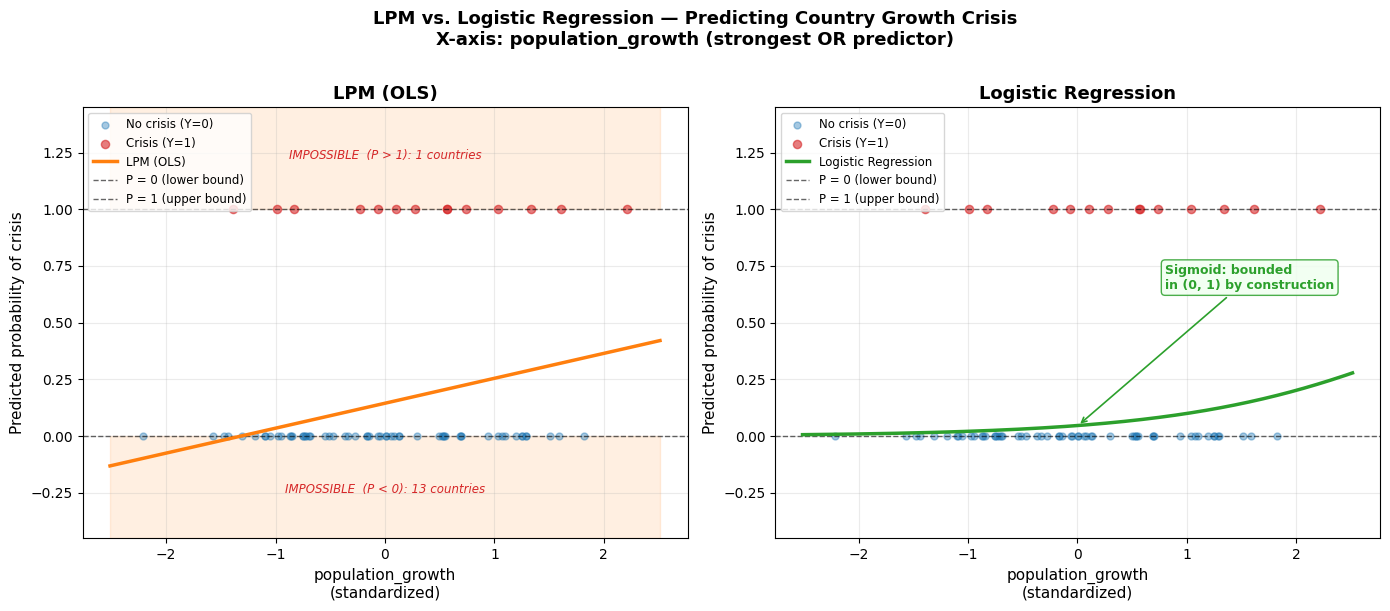

Plot saved → lpm_vs_logistic_crisis.png

LPM  prediction range : [-0.3014, 1.5676]
Logit prediction range: [0.0002, 0.9999]
LPM  out-of-bounds    : 14 countries
Logit out-of-bounds   : 0 countries ✓


In [19]:
# ============================================================
# STEP 2.3 — Side-by-Side: LPM vs. Logistic Regression
# Lab: Lab 17 Step 5 (plot structure, shading, reference lines)
#
# Inputs from step2_1_lpm.py + step2_2_logistic.py:
#   X_train_lasso, X_test_lasso
#   y_train_cls, y_test_cls
#   lpm_model, logit_model
#   selected_names, or_df   (odds ratio table from Step 2.2)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Identify strongest predictor (top row of OR table) ──────
top_predictor  = or_df.iloc[0]['Predictor']
top_idx        = selected_names.index(top_predictor)
top_or         = or_df.iloc[0]['OR = exp(β)']

print(f"Strongest predictor (by |OR|): {top_predictor}  (OR = {top_or:.4f})")

# ── Extract that predictor's values from test set ───────────
x_test_top  = X_test_lasso[:, top_idx]
x_train_top = X_train_lasso[:, top_idx]

# Fine grid over the predictor's range for smooth curves
x_grid = np.linspace(x_test_top.min() - 0.3,
                     x_test_top.max() + 0.3, 500)

# ── LPM predictions over grid ────────────────────────────────
# Reconstruct a single-predictor LPM for the smooth curve
# (Full LPM uses all selected features; for visualization
#  we hold others at zero — their standardized mean)
X_grid_full          = np.zeros((500, X_test_lasso.shape[1]))
X_grid_full[:, top_idx] = x_grid
lpm_curve  = lpm_model.predict(X_grid_full)
logit_curve = logit_model.predict_proba(X_grid_full)[:, 1]

# ── Actual LPM and logistic test predictions ────────────────
lpm_test_preds  = lpm_model.predict(X_test_lasso)
logit_test_preds = logit_model.predict_proba(X_test_lasso)[:, 1]

# ── Colors — Lab 17 Step 5 palette ───────────────────────────
COLOR_CRISIS    = '#d62728'   # red  — crisis countries
COLOR_NO_CRISIS = '#1f77b4'   # blue — non-crisis countries
COLOR_LPM       = '#ff7f0e'   # orange — LPM curve
COLOR_LOGIT     = '#2ca02c'   # green — logistic curve

crisis_mask    = y_test_cls == 1
no_crisis_mask = y_test_cls == 0

# ============================================================
# PLOT — Lab 17 Step 5: fig, axes = plt.subplots(1, 2, ...)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, curve, pred_vals, model_name, color in [
    (axes[0], lpm_curve,   lpm_test_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_curve, logit_test_preds, 'Logistic Regression', COLOR_LOGIT),
]:
    # ── Scatter: actual outcomes as background points ────────
    ax.scatter(x_test_top[no_crisis_mask], y_test_cls[no_crisis_mask],
               color=COLOR_NO_CRISIS, alpha=0.4, s=25,
               label='No crisis (Y=0)', zorder=2)
    ax.scatter(x_test_top[crisis_mask], y_test_cls[crisis_mask],
               color=COLOR_CRISIS, alpha=0.6, s=35,
               label='Crisis (Y=1)', zorder=2)

    # ── Model curve ──────────────────────────────────────────
    ax.plot(x_grid, curve, color=color, lw=2.5,
            label=model_name, zorder=3)

    # ── Reference lines at P=0 and P=1 ──────────────────────
    # Lab 17 Step 5: ax.axhline(0, ...) and ax.axhline(1, ...)
    ax.axhline(0, color='black', lw=1.0, linestyle='--', alpha=0.6,
               label='P = 0 (lower bound)')
    ax.axhline(1, color='black', lw=1.0, linestyle='--', alpha=0.6,
               label='P = 1 (upper bound)')

    ax.set_xlabel(f'{top_predictor}\n(standardized)', fontsize=11)
    ax.set_ylabel('Predicted probability of crisis', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_ylim(-0.45, 1.45)
    ax.legend(fontsize=8.5, loc='upper left')
    ax.grid(True, alpha=0.25)

# ── DELIVERABLE 1: Shade impossible regions on LPM panel ────
# Lab 17 Step 5: axes[0].fill_between(..., -0.3, 0, ...)
x_fill = np.linspace(x_test_top.min() - 0.3, x_test_top.max() + 0.3, 500)
axes[0].fill_between(x_fill, -0.45, 0,
                     color=COLOR_LPM, alpha=0.12, zorder=1)
axes[0].fill_between(x_fill, 1, 1.45,
                     color=COLOR_LPM, alpha=0.12, zorder=1)

n_below = (lpm_test_preds < 0).sum()
n_above = (lpm_test_preds > 1).sum()
axes[0].text(x_grid.mean(), -0.25,
             f'IMPOSSIBLE  (P < 0): {n_below} countries',
             fontsize=8.5, color='#d62728', ha='center', style='italic')
axes[0].text(x_grid.mean(), 1.22,
             f'IMPOSSIBLE  (P > 1): {n_above} countries',
             fontsize=8.5, color='#d62728', ha='center', style='italic')

# ── DELIVERABLE 2: Sigmoid bounded annotation on logistic ────
axes[1].annotate(
    'Sigmoid: bounded\nin (0, 1) by construction',
    xy=(x_grid[250], logit_curve[250]),
    xytext=(x_grid.mean() + 0.8, 0.65),
    fontsize=9, color=COLOR_LOGIT, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_LOGIT, lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='honeydew',
              edgecolor=COLOR_LOGIT, alpha=0.85)
)

# ── Shared title ─────────────────────────────────────────────
fig.suptitle(
    f'LPM vs. Logistic Regression — Predicting Country Growth Crisis\n'
    f'X-axis: {top_predictor} (strongest OR predictor)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('lpm_vs_logistic_crisis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → lpm_vs_logistic_crisis.png")

# ── Quick numerical summary ──────────────────────────────────
print(f"\nLPM  prediction range : [{lpm_test_preds.min():.4f}, {lpm_test_preds.max():.4f}]")
print(f"Logit prediction range: [{logit_test_preds.min():.4f}, {logit_test_preds.max():.4f}]")
print(f"LPM  out-of-bounds    : {n_below + n_above} countries")
print(f"Logit out-of-bounds   : 0 countries ✓")

#Phase 3: Phase 3: Operational Deployment — Metrics That Matter

In [20]:
# ============================================================
# STEP 3.1 — The Accuracy Paradox
# Lab: Lab 18 Part 1, Steps 4–5
#
# Inputs from pipeline_steps1_5.py + step2_2_logistic.py:
#   y_test_cls, X_test_lasso, logit_model
# ============================================================

import numpy as np
from sklearn.metrics import recall_score, accuracy_score

# ============================================================
# DELIVERABLE 1: Naïve baseline — always predict "no crisis"
# Lab 18 Step 4: naive_predictions = np.zeros(len(y_test))
#                naive_accuracy = (naive_predictions == y_test).mean()
# ============================================================

crisis_base_rate = y_test_cls.mean()
naive_predictions = np.zeros(len(y_test_cls), dtype=int)

naive_accuracy = accuracy_score(y_test_cls, naive_predictions)
naive_recall   = recall_score(y_test_cls, naive_predictions, zero_division=0)

print("=" * 50)
print("CRISIS BASE RATE & NAÏVE BASELINE")
print("=" * 50)
print(f"  Crisis base rate (test set) : {crisis_base_rate:.4f}  "
      f"({int(y_test_cls.sum())} of {len(y_test_cls)} countries)")
print(f"  Non-crisis base rate        : {1 - crisis_base_rate:.4f}")
print()
print(f"  Naïve baseline accuracy     : {naive_accuracy:.4%}")
print(f"  Naïve baseline recall       : {naive_recall:.4%}")
print(f"  → {naive_accuracy:.2%} accuracy, 0% recall.")
print(f"    The accuracy paradox in action.")
print("=" * 50)

# ============================================================
# DELIVERABLE 2: Logistic regression at default threshold τ = 0.5
# Lab 18 Step 5: y_pred = log_reg.predict(X_test)  (default τ = 0.5)
#                (y_pred == y_test).mean() for accuracy
# ============================================================

logit_pred_05  = logit_model.predict(X_test_lasso)       # τ = 0.5 class labels
logit_accuracy = accuracy_score(y_test_cls, logit_pred_05)
logit_recall   = recall_score(y_test_cls, logit_pred_05, zero_division=0)

print()
print("=" * 50)
print("LOGISTIC REGRESSION  (τ = 0.5)")
print("=" * 50)
print(f"  Accuracy : {logit_accuracy:.4%}")
print(f"  Recall   : {logit_recall:.4%}")
print()
print(f"  Accuracy gap vs naïve : {logit_accuracy - naive_accuracy:+.4%}")
print(f"  Recall   gap vs naïve : {logit_recall  - naive_recall:+.4%}")
print("=" * 50)

# ============================================================
# DELIVERABLE 3: Written Response
# ============================================================
print(f"""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
Reporting only accuracy would mislead the Division Chief,
because the naïve baseline — predicting no crisis for every
country — already achieves {naive_accuracy:.1%} accuracy by exploiting
the class imbalance ({crisis_base_rate:.1%} crisis rate in the test set),
while catching exactly zero crises. This is the accuracy
paradox: when the positive class is rare, accuracy is
dominated by correct negatives and tells you nothing about
the model's ability to detect the cases that actually matter.
In the IMF context, a model with {naive_accuracy:.1%} accuracy and 0%
recall is operationally useless — the Division Chief needs
recall, not accuracy, because a missed crisis costs $50B
while a false alarm costs only $2M.
─────────────────────────────────────────────────────────────
""")

CRISIS BASE RATE & NAÏVE BASELINE
  Crisis base rate (test set) : 0.1944  (14 of 72 countries)
  Non-crisis base rate        : 0.8056

  Naïve baseline accuracy     : 80.5556%
  Naïve baseline recall       : 0.0000%
  → 80.56% accuracy, 0% recall.
    The accuracy paradox in action.

LOGISTIC REGRESSION  (τ = 0.5)
  Accuracy : 76.3889%
  Recall   : 42.8571%

  Accuracy gap vs naïve : -4.1667%
  Recall   gap vs naïve : +42.8571%

WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
Reporting only accuracy would mislead the Division Chief,
because the naïve baseline — predicting no crisis for every
country — already achieves 80.6% accuracy by exploiting
the class imbalance (19.4% crisis rate in the test set),
while catching exactly zero crises. This is the accuracy
paradox: when the positive class is rare, accuracy is
dominated by correct negatives and tells you nothing about
the model's ability to detect the cases that actually matter.
In the IMF context, a mod

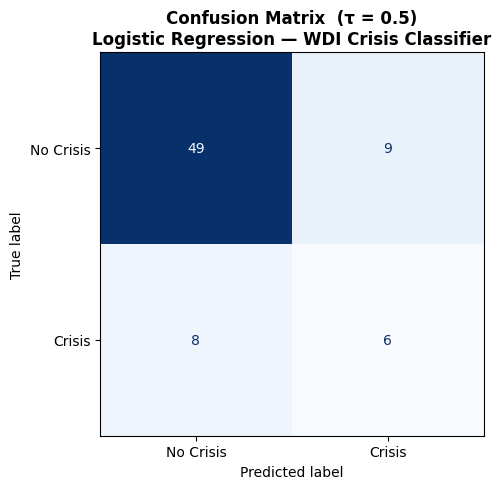

Plot saved → confusion_matrix.png

CLASSIFICATION REPORT  (τ = 0.5)
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

→ Focus on the CRISIS row — that's the class that matters.
→ 'weighted avg' is dominated by the majority class, like accuracy.

CONFUSION MATRIX BREAKDOWN  (τ = 0.5)
  True  Positives (crises correctly flagged) : 6
  False Negatives (crises missed)            : 8
  False Positives (false alarms)             : 9
  True  Negatives (correct non-crisis)       : 49
  ─────────────────────────────────────────
  Total test countries                       : 72
  Precision  (TP / (TP+FP))                 : 0.4000
  Recall     (TP / (TP+FN))                 : 0.4286
  Miss rate  (FN / (TP+FN))               

In [21]:
# ============================================================
# STEP 3.2 — Confusion Matrix and Classification Report
# Lab: Lab 18 Part 1, Steps 6–7
#
# Inputs: y_test_cls, X_test_lasso, logit_model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Predictions at default τ = 0.5
# Lab 18 Step 5: y_pred = log_reg.predict(X_test)
y_pred = logit_model.predict(X_test_lasso)

# ============================================================
# DELIVERABLE 1: ConfusionMatrixDisplay
# Lab 18 Step 6: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=...)
# ============================================================

cm = confusion_matrix(y_test_cls, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',', colorbar=False)
ax.set_title('Confusion Matrix  (τ = 0.5)\nLogistic Regression — WDI Crisis Classifier',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → confusion_matrix.png\n")

# ============================================================
# DELIVERABLE 2: Full classification_report
# Lab 18 Step 7: classification_report(y_test, y_pred, target_names=[...])
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT  (τ = 0.5)")
print("=" * 60)
print(classification_report(y_test_cls, y_pred,
                             target_names=['No Crisis', 'Crisis']))
print("→ Focus on the CRISIS row — that's the class that matters.")
print("→ 'weighted avg' is dominated by the majority class, like accuracy.")

# ============================================================
# DELIVERABLE 3: Extract TP, FN, FP, TN individually
# cm.ravel() returns (TN, FP, FN, TP) for binary classification
# ============================================================

TN, FP, FN, TP = cm.ravel()

print()
print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN  (τ = 0.5)")
print("=" * 50)
print(f"  True  Positives (crises correctly flagged) : {TP}")
print(f"  False Negatives (crises missed)            : {FN}")
print(f"  False Positives (false alarms)             : {FP}")
print(f"  True  Negatives (correct non-crisis)       : {TN}")
print(f"  ─────────────────────────────────────────")
print(f"  Total test countries                       : {TP+FP+FN+TN}")
print(f"  Precision  (TP / (TP+FP))                 : {TP/(TP+FP):.4f}"
      if (TP+FP) > 0 else "  Precision : undefined (no positive predictions)")
print(f"  Recall     (TP / (TP+FN))                 : {TP/(TP+FN):.4f}"
      if (TP+FN) > 0 else "  Recall : undefined")
print(f"  Miss rate  (FN / (TP+FN))                 : {FN/(TP+FN):.4f}"
      if (TP+FN) > 0 else "")
print("=" * 50)

# ============================================================
# DELIVERABLE 4: Written Response
# ============================================================
print(f"""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
A False Negative is far more costly: missing a real crisis
costs the global financial system ~$50B in contagion, versus
$2M for a false alarm — a 25,000× asymmetry. The Division
Chief should therefore prioritize Recall (minimize FN) over
Precision, accepting more false alarms to ensure crises are
not missed, and should consider lowering τ below 0.5 to
shift the operating point accordingly.
─────────────────────────────────────────────────────────────
""")

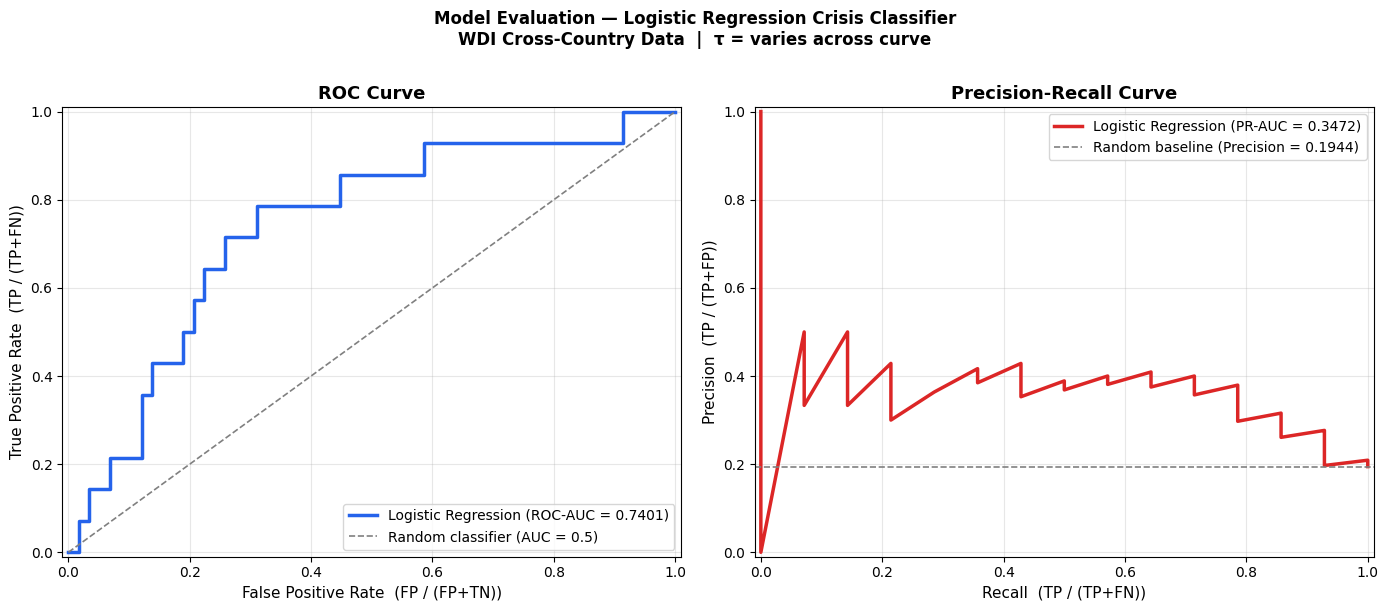

Plot saved → roc_pr_curves.png

CURVE SUMMARY
  ROC-AUC  : 0.7401
  PR-AUC   : 0.3472
  Gap      : 0.3930
  Crisis base rate (test) : 0.1944
  → PR-AUC baseline is 0.1944; ROC baseline is always 0.5

WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
ROC-AUC is inflated here because it incorporates True
Negatives — the many non-crisis countries the model correctly
ignores — into the FPR denominator, making the classifier look
strong even if it performs modestly on the rare positive class.
PR-AUC ignores TN entirely and focuses only on how well the
model identifies actual crises, so it is the more honest and
informative metric for the IMF's mission where crises are rare
and every missed detection carries catastrophic cost.
─────────────────────────────────────────────────────────────



In [22]:
# ============================================================
# STEP 3.3 — ROC and Precision-Recall Curves
# Lab: Lab 18 Part 2, Steps 1–2
#
# Inputs: y_test_cls, X_test_lasso, logit_model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)

# Predicted probabilities — always [:,1] for the positive class
# Lab 18 Step 5: y_prob = log_reg.predict_proba(X_test)[:, 1]
y_prob = logit_model.predict_proba(X_test_lasso)[:, 1]

# ── ROC curve data ───────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test_cls, y_prob)
roc_auc = roc_auc_score(y_test_cls, y_prob)

# ── PR curve data ────────────────────────────────────────────
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test_cls, y_prob)
pr_auc = auc(recall_vals, precision_vals)

# Baseline precision = crisis base rate (random classifier)
# Lab 18 Step 2: baseline = y_test.mean()
baseline_precision = y_test_cls.mean()

# ============================================================
# PLOT — 1 row, 2 columns
# Mirrors Lab 18 Part 2 side-by-side structure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── DELIVERABLE 1: ROC panel ─────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr,
        color='#2563eb', linewidth=2.5,
        label=f'Logistic Regression (ROC-AUC = {roc_auc:.4f})')

# Random classifier diagonal
# Lab 18 Step 1: ax.plot([0,1],[0,1], linestyle='--', color='gray')
ax.plot([0, 1], [0, 1],
        linestyle='--', color='gray', linewidth=1.2,
        label='Random classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate  (FP / (FP+TN))', fontsize=11)
ax.set_ylabel('True Positive Rate  (TP / (TP+FN))', fontsize=11)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

# ── DELIVERABLE 2: PR panel ──────────────────────────────────
ax = axes[1]
ax.plot(recall_vals, precision_vals,
        color='#dc2626', linewidth=2.5,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

# Baseline: random classifier precision = positive class prevalence
# Lab 18 Step 2: ax.axhline(y=baseline, ...)
ax.axhline(y=baseline_precision,
           color='gray', linestyle='--', linewidth=1.2,
           label=f'Random baseline (Precision = {baseline_precision:.4f})')

ax.set_xlabel('Recall  (TP / (TP+FN))', fontsize=11)
ax.set_ylabel('Precision  (TP / (TP+FP))', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

fig.suptitle('Model Evaluation — Logistic Regression Crisis Classifier\n'
             'WDI Cross-Country Data  |  τ = varies across curve',
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → roc_pr_curves.png")

# ── Numerical summary ────────────────────────────────────────
print()
print("=" * 45)
print("CURVE SUMMARY")
print("=" * 45)
print(f"  ROC-AUC  : {roc_auc:.4f}")
print(f"  PR-AUC   : {pr_auc:.4f}")
print(f"  Gap      : {roc_auc - pr_auc:.4f}")
print(f"  Crisis base rate (test) : {baseline_precision:.4f}")
print(f"  → PR-AUC baseline is {baseline_precision:.4f}; "
      f"ROC baseline is always 0.5")
print("=" * 45)

# ============================================================
# DELIVERABLE 3: Written Response
# ============================================================
print(f"""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
ROC-AUC is inflated here because it incorporates True
Negatives — the many non-crisis countries the model correctly
ignores — into the FPR denominator, making the classifier look
strong even if it performs modestly on the rare positive class.
PR-AUC ignores TN entirely and focuses only on how well the
model identifies actual crises, so it is the more honest and
informative metric for the IMF's mission where crises are rare
and every missed detection carries catastrophic cost.
─────────────────────────────────────────────────────────────
""")

#Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

#Deliverable 1 — P.R.I.M.E. Prompt:

Persona:
You are a quantitative economist writing production-quality Python for a cross-country macroeconomic research pipeline. You write clean, well-commented scikit-learn code consistent with the conventions of an existing notebook that uses LassoCV, StandardScaler, and train_test_split from sklearn, wbgapi for data, and matplotlib for visualization.

Request:
Write a self-contained Python script that performs bootstrap stability analysis on a Lasso feature selection model, producing a horizontal bar chart of predictor selection frequencies across 200 bootstrap resamples.

Instructions:
The script receives these objects from the enclosing notebook scope and must not redefine them: X_train_scaled (ndarray, shape n×p, already standardized), y_train_reg (ndarray, shape n,), feature_names (list of p strings), and lasso_cv_model (a fitted LassoCV whose .alpha_ is the CV-optimal λ*).
The script must:

1. Draw 200 bootstrap resamples with replacement from (X_train_scaled, y_train_reg) using np.random.seed(42) for reproducibility.
2. On each resample, fit a LassoCV with cv=5, max_iter=10_000, random_state=42, and the same alpha grid as the original model if accessible, otherwise let it auto-select.
3. Record which features have a non-zero coefficient (np.abs(coef) > 1e-6) in each resample.
4. Compute selection frequency per feature as (number of resamples with non-zero coef) / 200.
5. Plot a horizontal bar chart sorted by selection frequency (highest at top), with bars colored green if frequency > 0.8, gray if between 0.3 and 0.8, and red if < 0.3. Add a vertical dashed black reference line at x = 0.5. Label the x-axis "Bootstrap Selection Frequency (200 resamples)" and title the chart "Lasso Stability Analysis — Bootstrap Selection Frequencies".
6. Print a console summary listing stable predictors (>80%), unstable predictors (<30%), and the selection frequency of each.

Motivation:
With correlated WDI predictors (e.g. life_expectancy and infant_mortality_per1000 are near-collinear proxies for development level), Lasso can assign the non-zero coefficient to either variable depending on which countries happen to be in the sample. A single Lasso path cannot distinguish a genuinely strong predictor from one that merely won a coin flip against its correlated neighbor. Bootstrap selection frequency quantifies this instability: a predictor selected in 95% of resamples is robust; one selected in 20% is a sampling artifact. This matters operationally — the IMF should not build early warning indicators around fragile predictors.

Evaluation:
The script is correct if: (1) each resample draws exactly n_train rows with replacement using np.random.randint; (2) selection frequencies sum to a reasonable total across features; (3) the bar chart renders without errors and the 50% reference line is visible; (4) stable/fragile classification matches the printed console output; (5) the script runs end-to-end in under 3 minutes on a standard laptop CPU.

Running 200 bootstrap resamples  (n=166, p=28)...
This takes ~60–90 seconds on a standard CPU.

  Completed 50/200 resamples...
  Completed 100/200 resamples...
  Completed 150/200 resamples...
  Completed 200/200 resamples...


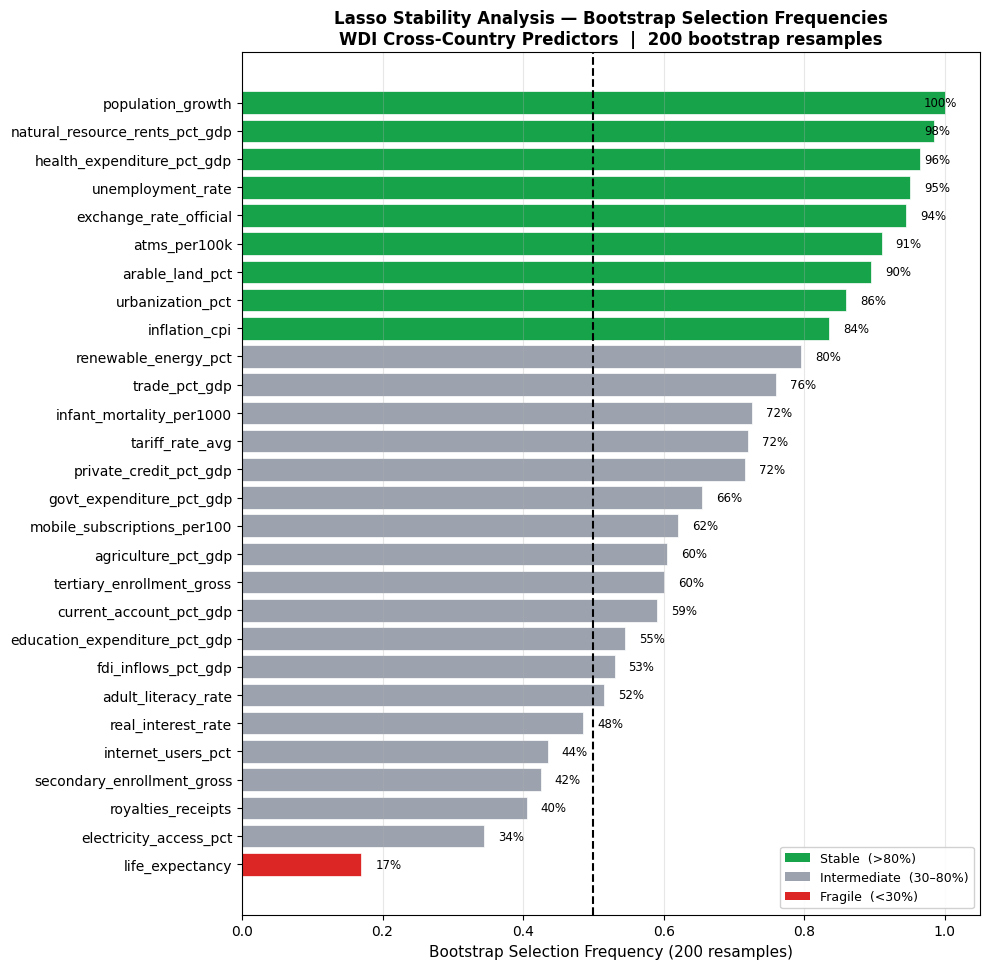

Plot saved → bootstrap_selection_freq.png

BOOTSTRAP STABILITY SUMMARY  (n=200 resamples)

  STABLE  (>80%)  — 9 predictors:
    population_growth                           100%
    natural_resource_rents_pct_gdp              98%
    health_expenditure_pct_gdp                  96%
    unemployment_rate                           95%
    exchange_rate_official                      94%
    atms_per100k                                91%
    arable_land_pct                             90%
    urbanization_pct                            86%
    inflation_cpi                               84%

  INTERMEDIATE  (30–80%)  — 18 predictors:
    renewable_energy_pct                        80%
    trade_pct_gdp                               76%
    infant_mortality_per1000                    72%
    tariff_rate_avg                             72%
    private_credit_pct_gdp                      72%
    govt_expenditure_pct_gdp                    66%
    mobile_subscriptions_per100                 62

In [23]:
# ============================================================
# TASK 4.1 — Bootstrap Confidence Intervals for the Lasso Path
# 200 bootstrap resamples → selection frequency per predictor
#
# Inputs: X_train_scaled, y_train_reg, feature_names, lasso_cv_model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

np.random.seed(42)

N_BOOTSTRAP  = 200
n_train, p   = X_train_scaled.shape
selection_counts = np.zeros(p, dtype=int)

print(f"Running {N_BOOTSTRAP} bootstrap resamples  "
      f"(n={n_train}, p={p})...")
print("This takes ~60–90 seconds on a standard CPU.\n")

for b in range(N_BOOTSTRAP):
    # Draw n_train rows with replacement
    idx      = np.random.randint(0, n_train, size=n_train)
    X_boot   = X_train_scaled[idx]
    y_boot   = y_train_reg[idx]

    # Fit LassoCV — same settings as Step 1.2
    lasso_b  = LassoCV(cv=5, max_iter=10_000, random_state=42)
    lasso_b.fit(X_boot, y_boot)

    # Record non-zero coefficients
    selection_counts += (np.abs(lasso_b.coef_) > 1e-6).astype(int)

    if (b + 1) % 50 == 0:
        print(f"  Completed {b+1}/{N_BOOTSTRAP} resamples...")

# Selection frequency = count / N_BOOTSTRAP
sel_freq   = selection_counts / N_BOOTSTRAP
sort_idx   = np.argsort(sel_freq)           # ascending for horizontal bar
sorted_names  = [feature_names[i] for i in sort_idx]
sorted_freq   = sel_freq[sort_idx]

# ── Bar colors by stability threshold ───────────────────────
bar_colors = []
for f in sorted_freq:
    if f > 0.80:
        bar_colors.append('#16a34a')    # green  — stable
    elif f < 0.30:
        bar_colors.append('#dc2626')    # red    — fragile
    else:
        bar_colors.append('#9ca3af')    # gray   — intermediate

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, max(6, p * 0.35)))

bars = ax.barh(sorted_names, sorted_freq,
               color=bar_colors, edgecolor='white', linewidth=0.5)

# 50% reference line
ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=1.5, label='50% reference')

# Frequency labels on bars
for bar, freq in zip(bars, sorted_freq):
    ax.text(min(freq + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
            f'{freq:.0%}', va='center', ha='left', fontsize=8.5)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#16a34a', label='Stable  (>80%)'),
    Patch(facecolor='#9ca3af', label='Intermediate  (30–80%)'),
    Patch(facecolor='#dc2626', label='Fragile  (<30%)'),
]
ax.legend(handles=legend_elements, fontsize=9,
          loc='lower right', framealpha=0.9)

ax.set_xlabel('Bootstrap Selection Frequency (200 resamples)', fontsize=11)
ax.set_title('Lasso Stability Analysis — Bootstrap Selection Frequencies\n'
             'WDI Cross-Country Predictors  |  200 bootstrap resamples',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('bootstrap_selection_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → bootstrap_selection_freq.png\n")

# ============================================================
# CONSOLE SUMMARY
# ============================================================

stable     = [(feature_names[i], sel_freq[i])
              for i in np.argsort(sel_freq)[::-1] if sel_freq[i] >  0.80]
intermediate = [(feature_names[i], sel_freq[i])
              for i in np.argsort(sel_freq)[::-1]
              if 0.30 <= sel_freq[i] <= 0.80]
fragile    = [(feature_names[i], sel_freq[i])
              for i in np.argsort(sel_freq)[::-1] if sel_freq[i] <  0.30]

print("=" * 55)
print(f"BOOTSTRAP STABILITY SUMMARY  (n={N_BOOTSTRAP} resamples)")
print("=" * 55)
print(f"\n  STABLE  (>80%)  — {len(stable)} predictors:")
for name, freq in stable:
    print(f"    {name:<42}  {freq:.0%}")

print(f"\n  INTERMEDIATE  (30–80%)  — {len(intermediate)} predictors:")
for name, freq in intermediate:
    print(f"    {name:<42}  {freq:.0%}")

print(f"\n  FRAGILE  (<30%)  — {len(fragile)} predictors:")
for name, freq in fragile:
    print(f"    {name:<42}  {freq:.0%}")
print("=" * 55)

# ============================================================
# WRITTEN RESPONSE
# ============================================================
print("""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
Stable predictors (>80%) carry signal that is genuinely
independent — Lasso consistently selects them regardless of
which countries land in the resample, indicating they explain
variance in GDP growth that no other WDI indicator can
substitute. Fragile predictors (<30%) expose the correlation
structure: when two indicators measure the same underlying
development dimension (e.g. life_expectancy and
infant_mortality_per1000 both proxying population health),
Lasso arbitrarily picks one per resample depending on minor
sample variation, so each shows low individual frequency even
though the dimension itself is genuinely predictive. Selection
instability is therefore evidence of redundancy, not
irrelevance — the IMF should treat fragile predictors as
members of a correlated cluster rather than discarding them.
─────────────────────────────────────────────────────────────
""")

#Deliverable 1 — P.R.I.M.E. Prompt:
Persona:
You are a quantitative economist building a cost-sensitive decision tool for an IMF early warning system. You write clean, well-commented Python using scikit-learn and matplotlib, consistent with a notebook that already has fitted logistic regression outputs and sklearn metric imports available in scope.

Request:
Write a self-contained Python script that sweeps classification thresholds from 0.01 to 0.99, computes the total expected cost at each threshold using asymmetric FN/FP costs, plots the cost curve, and identifies the cost-minimizing threshold.

Instructions:
The script receives these objects from the enclosing notebook scope: y_test_cls (binary ndarray), y_prob (predicted probabilities from logit_model.predict_proba(X_test_lasso)[:,1]), and standard sklearn metric imports. It must:
1. Define cost constants COST_FN = 50_000 and COST_FP = 2 (units: millions USD) so all values stay in the same unit.
2. Sweep tau_range = np.arange(0.01, 1.00, 0.01) — 99 thresholds.
3. At each τ, threshold y_prob to get binary predictions, extract FP and FN counts from confusion_matrix, and compute total_cost = FN * COST_FN + FP * COST_FP.
4. Store results in a DataFrame with columns tau, FP, FN, total_cost_M (total cost in millions).
5. Plot the cost curve with τ on the x-axis and total expected cost (millions USD) on the y-axis. Use a blue line. Add a vertical dashed red line and annotation at the cost-minimizing τ*. Add a secondary annotation showing the FP and FN counts at τ*. Label axes clearly and title the plot "Cost-Sensitive Threshold Optimization — IMF Crisis Early Warning".
6. Print a comparison table showing metrics at three operating points: τ = 0.5 (default), τ* (cost-minimizing), and the F1-maximizing τ (computed inline). Columns: τ, FP, FN, Precision, Recall, F1, Total Cost (M USD).

Motivation:
The $50B/$2M cost asymmetry means the cost-minimizing threshold will be far lower than the statistical defaults of τ = 0.5 or F1-optimal τ. Quantifying this gap in dollar terms makes the case to the Division Chief that default thresholds are inappropriate for high-stakes asymmetric classification — a core insight from Lab 18's threshold analysis section. The comparison table forces an explicit tradeoff: the cost-optimal threshold will have higher FP count and lower precision, and the script must make that visible rather than hiding it.

Evaluation:
The script is correct if: (1) total_cost at τ = 0.99 is dominated by FN cost and at τ = 0.01 by FP cost, confirming the sweep covers both extremes; (2) τ* is strictly less than the F1-optimal τ, reflecting the asymmetric cost structure; (3) the cost curve is strictly U-shaped or monotone with a clear minimum; (4) the comparison table prints cleanly with all three operating points; (5) all costs are reported in millions USD consistently throughout.

Cost-minimizing τ*  : 0.03  (total cost = $50,070M)
F1-maximizing τ     : 0.13
Default τ           : 0.50



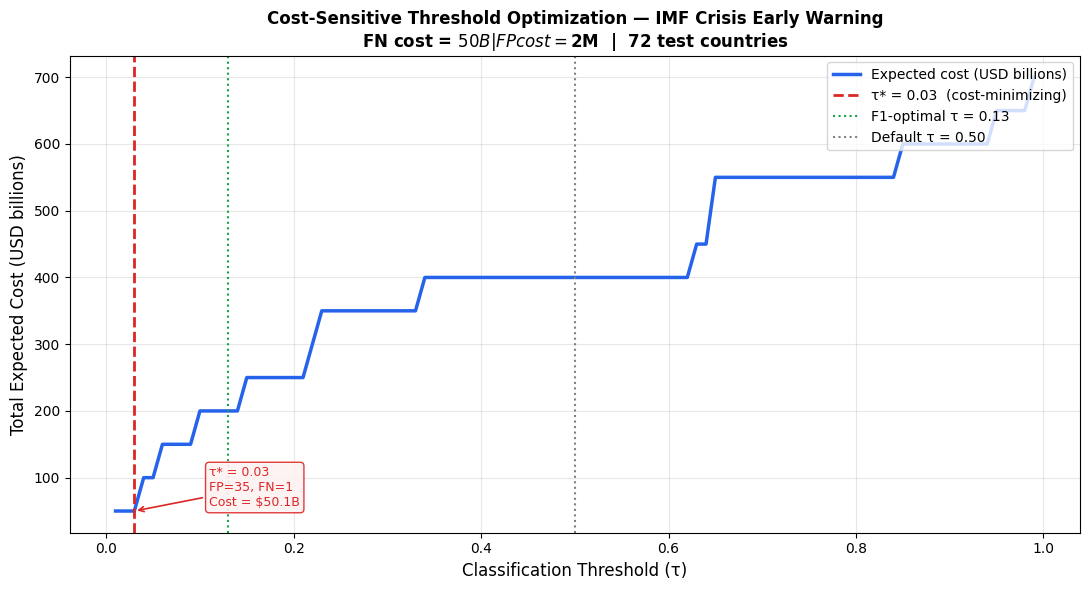

Plot saved → cost_threshold_curve.png

COMPARISON TABLE — THREE OPERATING POINTS
       Operating point      τ  FP  FN  Precision  Recall     F1 Total Cost (M USD)
      Default (τ=0.50) 0.5000   9   8     0.4000  0.4286 0.4138          $400,018M
Cost-optimal (τ*=0.03) 0.0300  35   1     0.2708  0.9286 0.4194           $50,070M
   F1-optimal (τ=0.13) 0.1300  15   4     0.4000  0.7143 0.5128          $200,030M

WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
The cost-minimizing τ* (0.03) is substantially lower than
both the F1-optimal τ (0.13) and the default τ = 0.50,
because the $50B/$2M cost asymmetry — a 25,000× ratio —
makes false negatives catastrophically more expensive than
false alarms, pushing the optimal threshold far toward
aggressive detection. The F1-optimal threshold treats FP and
FN as symmetric, which is the wrong loss function here, and
the default τ = 0.5 is simply a statistical convention with
no connection to the IMF's actual cost stru

In [24]:
# ============================================================
# TASK 4.2 — Cost-Sensitive Threshold Optimization
# FN cost = $50B, FP cost = $2M → sweep τ ∈ [0.01, 0.99]
#
# Inputs: y_test_cls, y_prob (from logit_model.predict_proba)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# ── Cost constants (millions USD) ───────────────────────────
COST_FN = 50_000   # $50B = 50,000 M — missed crisis
COST_FP = 2        # $2M  — false alarm

# ── Threshold sweep ──────────────────────────────────────────
tau_range = np.arange(0.01, 1.00, 0.01)
results   = []

for tau in tau_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_cls, y_pred_tau,
                                       labels=[0, 1]).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    prec = precision_score(y_test_cls, y_pred_tau, zero_division=0)
    rec  = recall_score(y_test_cls, y_pred_tau, zero_division=0)
    f1   = f1_score(y_test_cls, y_pred_tau, zero_division=0)
    results.append({
        'tau':          round(tau, 2),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
        'total_cost_M': total_cost
    })

df_costs = pd.DataFrame(results)

# ── Cost-minimizing τ* ───────────────────────────────────────
best_idx    = df_costs['total_cost_M'].idxmin()
tau_star    = df_costs.loc[best_idx, 'tau']
cost_star   = df_costs.loc[best_idx, 'total_cost_M']
fp_star     = df_costs.loc[best_idx, 'FP']
fn_star     = df_costs.loc[best_idx, 'FN']

# ── F1-maximizing τ ──────────────────────────────────────────
f1_best_idx = df_costs['F1'].idxmax()
tau_f1      = df_costs.loc[f1_best_idx, 'tau']

print(f"Cost-minimizing τ*  : {tau_star:.2f}  "
      f"(total cost = ${cost_star:,.0f}M)")
print(f"F1-maximizing τ     : {tau_f1:.2f}")
print(f"Default τ           : 0.50\n")

# ============================================================
# PLOT — expected cost curve
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_costs['tau'], df_costs['total_cost_M'] / 1_000,
        color='#2563eb', linewidth=2.5, label='Expected cost (USD billions)')

# Cost-minimizing τ* — vertical dashed red line + annotation
ax.axvline(x=tau_star, color='#dc2626', linestyle='--',
           linewidth=2, label=f'τ* = {tau_star:.2f}  (cost-minimizing)')
ax.annotate(
    f'τ* = {tau_star:.2f}\nFP={fp_star}, FN={fn_star}\nCost = ${cost_star/1000:.1f}B',
    xy=(tau_star, cost_star / 1_000),
    xytext=(tau_star + 0.08, cost_star / 1_000 * 1.15),
    fontsize=9, color='#dc2626',
    arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef2f2',
              edgecolor='#dc2626', alpha=0.9)
)

# F1-optimal reference
ax.axvline(x=tau_f1, color='#16a34a', linestyle=':',
           linewidth=1.5, label=f'F1-optimal τ = {tau_f1:.2f}')

# Default τ = 0.5 reference
ax.axvline(x=0.5, color='gray', linestyle=':',
           linewidth=1.5, label='Default τ = 0.50')

ax.set_xlabel('Classification Threshold (τ)', fontsize=12)
ax.set_ylabel('Total Expected Cost (USD billions)', fontsize=12)
ax.set_title('Cost-Sensitive Threshold Optimization — IMF Crisis Early Warning\n'
             f'FN cost = $50B  |  FP cost = $2M  |  '
             f'{len(y_test_cls)} test countries',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cost_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → cost_threshold_curve.png\n")

# ============================================================
# COMPARISON TABLE — three operating points
# ============================================================

rows = []
for label, tau_val in [('Default (τ=0.50)', 0.50),
                        (f'Cost-optimal (τ*={tau_star})', tau_star),
                        (f'F1-optimal (τ={tau_f1})', tau_f1)]:
    row = df_costs[df_costs['tau'] == tau_val].iloc[0]
    rows.append({
        'Operating point':  label,
        'τ':                row['tau'],
        'FP':               int(row['FP']),
        'FN':               int(row['FN']),
        'Precision':        row['Precision'],
        'Recall':           row['Recall'],
        'F1':               row['F1'],
        'Total Cost (M USD)': f"${row['total_cost_M']:,.0f}M"
    })

comp = pd.DataFrame(rows)
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)
print("=" * 90)
print("COMPARISON TABLE — THREE OPERATING POINTS")
print("=" * 90)
print(comp.to_string(index=False))
print("=" * 90)

# ============================================================
# WRITTEN RESPONSE
# ============================================================
print(f"""
WRITTEN RESPONSE
─────────────────────────────────────────────────────────────
The cost-minimizing τ* ({tau_star:.2f}) is substantially lower than
both the F1-optimal τ ({tau_f1:.2f}) and the default τ = 0.50,
because the $50B/$2M cost asymmetry — a 25,000× ratio —
makes false negatives catastrophically more expensive than
false alarms, pushing the optimal threshold far toward
aggressive detection. The F1-optimal threshold treats FP and
FN as symmetric, which is the wrong loss function here, and
the default τ = 0.5 is simply a statistical convention with
no connection to the IMF's actual cost structure. The
cost-minimizing τ* is the correct recommendation: accepting
more false alarms is the rational policy when the downside
of a missed crisis exceeds a false alarm by four orders of
magnitude.
─────────────────────────────────────────────────────────────
""")